<a href="https://colab.research.google.com/github/raid4shoots-sudo/chaine-of-life/blob/main/TP3_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP3: Classification Models and Evaluation Metrics

**Nom et Prénom:** Khennane Raid

# Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets as load_iris
import sklearn.model_selection as train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

# Load Dataset

In [2]:
iris = load_iris.load_iris()
X = iris.data                                                                     # Extract the input features (X)
y = iris.target                                                                   # Extract the class labels (y)

In [3]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [4]:
sizeofX = X.shape
print(sizeofX)

(150, 4)


# Convert to Binary Classification

In [5]:
# Convert the multi-class labels into binary labels
# Setosa (class 0) becomes 1
# Other classes become 0

y_binary = (y == 0).astype(int)

In [6]:
(y == 0)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [7]:
(y == 0).astype(int)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Train/Test Split

In [8]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split.train_test_split(X, y_binary, test_size=0.3, random_state=42, stratify=y_binary)  # ensures both sets contain similar proportions of Setosa and Not Setosa.

In [9]:
print(f"X_train shape: {X.shape}")
print(f"y_train shape: {y_binary.shape}")

X_train shape: (150, 4)
y_train shape: (150,)


# Feature Scaling

In [10]:
# Initialize the scaler
scaler = StandardScaler()

# Compute mean and std from training data then scale it
X_train = scaler.fit_transform(X_train)

# Apply the same transformation to the test data
X_test = scaler.transform(X_test)

# Display Samples and Dataset Shapes

In [11]:
# Display first 5 training samples
print("First training samples:")
print(X_train[:5])

# Display first 5 test samples
print("First test samples:")
print(X_test[:5])

# Display dataset shapes
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

First training samples:
[[-0.16677192 -0.32295137  0.27470219  0.16778873]
 [-0.28837645 -1.24566957  0.10094478 -0.10325461]
 [ 1.41408694  0.36908728  0.56429788  0.3033104 ]
 [-1.01800362  1.06112593 -1.23119538 -0.78086296]
 [ 0.92766883 -0.09227182  0.39054047  0.3033104 ]]
First test samples:
[[-1.01800362  0.83044638 -1.28911451 -1.32294964]
 [ 1.29248241  0.13840773  0.79597443  1.52300543]
 [-0.40998098  2.67588278 -1.34703365 -1.32294964]
 [ 0.07643713  0.36908728  0.62221702  0.84539708]
 [-0.77479456  1.06112593 -1.28911451 -1.32294964]]
Training set shape: (105, 4)
Test set shape: (45, 4)
Training labels shape: (105,)
Test labels shape: (45,)


# Train the Classification Models

In [12]:
# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=200)                                       # max_iter allows enough iterations for convergence.

# Create the SVM model using a linear kernel
svm_model = SVC(kernel='linear', probability=True)                               # linear decision boundary and allows probability prediction (needed for ROC curves).

# Create the Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)                             # random_state for reproducibility (tree structure).

In [13]:
# Train logistic regression
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [14]:
# Train SVM
svm_model.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [15]:
# Train Decision Tree
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [16]:
# Predict labels on test dataset

y_pred_log = log_reg.predict(X_test)
y_pred_svm = svm_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)

# Compute Evaluation Metrics

In [17]:
def evaluate_model(y_test, y_pred, model_name):

    print("\nResults for", model_name)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    # Precision
    prec = precision_score(y_test, y_pred)
    print("Precision:", prec)

    # Recall
    rec = recall_score(y_test, y_pred)
    print("Recall:", rec)

    # F1 Score
    f1 = f1_score(y_test, y_pred)
    print("F1-score:", f1)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("Confusion Matrix:")
    print(cm)

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title(model_name)
    plt.show()


Results for Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Confusion Matrix:
[[30  0]
 [ 0 15]]


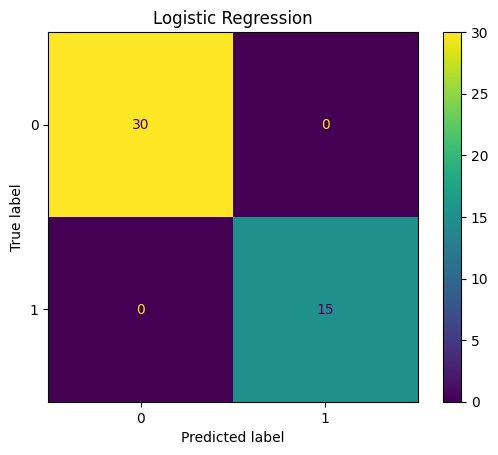


Results for SVM
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Confusion Matrix:
[[30  0]
 [ 0 15]]


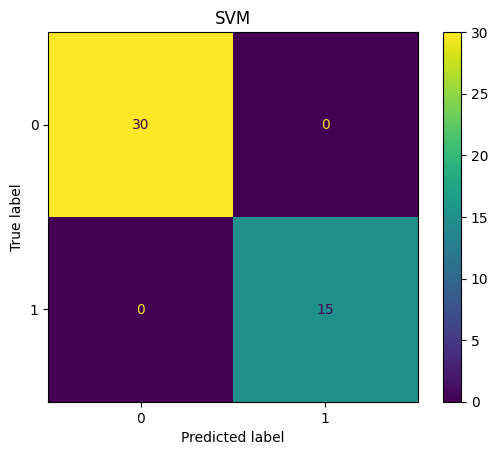


Results for Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Confusion Matrix:
[[30  0]
 [ 0 15]]


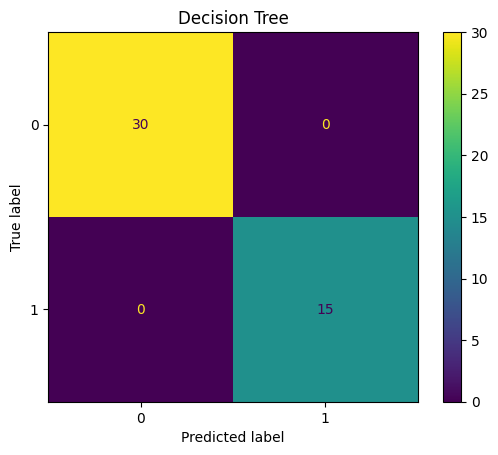

In [18]:
evaluate_model(y_test, y_pred_log, "Logistic Regression")                        # Uses a mathematical function called the sigmoid (logistic) function to map values between 0 and 1.
evaluate_model(y_test, y_pred_svm, "SVM")                                        # It tries to find the best boundary (hyperplane) that separates different classes.
evaluate_model(y_test, y_pred_tree, "Decision Tree")                             # It makes decisions step-by-step like a flowchart.

### Plot ROC Curves for Binary Classification

In [19]:
y_prob_log_binary = log_reg.predict_proba(X_test)
y_prob_svm_binary = svm_model.predict_proba(X_test)
y_prob_tree_binary = tree_model.predict_proba(X_test)

print("Prediction probabilities obtained for binary classification models.")

Prediction probabilities obtained for binary classification models.


### Get Prediction Probabilities for Binary Classification

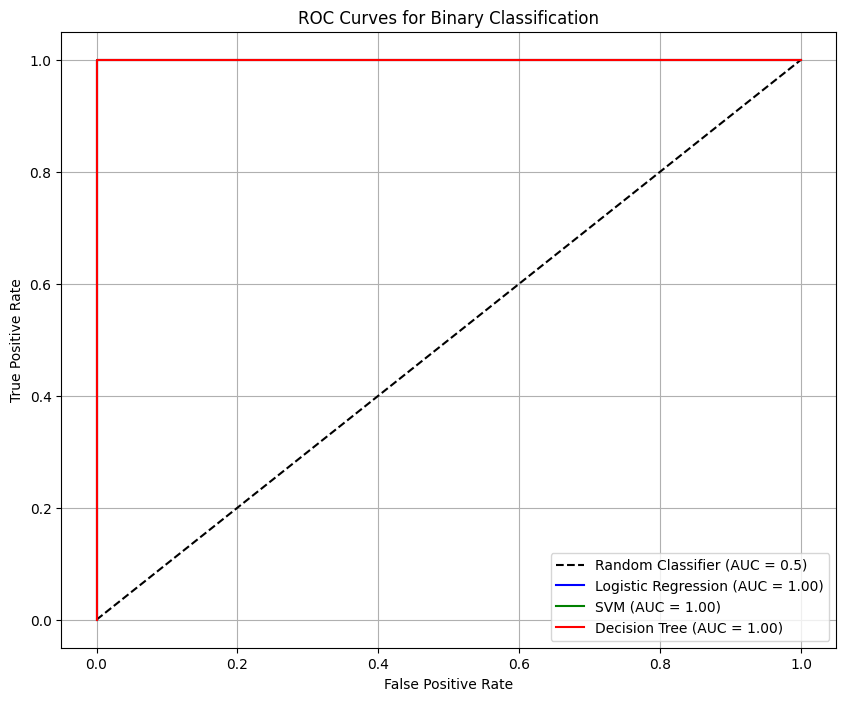

In [20]:
# Create a new figure for plotting with a larger size (10x8 inches)
plt.figure(figsize=(10, 8))

# Plot the diagonal line (baseline)
# This represents a random classifier (no skill)
# If your model is not better than this line → it's useless
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')           # 'k--' black dashed line (reference line)

# Dictionary that contains model names and their predicted probabilities
models_binary_data = {
    "Logistic Regression": y_prob_log_binary,
    "SVM": y_prob_svm_binary,
    "Decision Tree": y_prob_tree_binary
}

colors = ['b', 'g', 'r']

# Loop through each model
for i, (model_name, y_prob_data) in enumerate(models_binary_data.items()):
    # For binary classification, we only care about the probability of the positive class (class 1)
    fpr, tpr, _ = roc_curve(y_test, y_prob_data[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})', color=colors[i])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Binary Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Plot Precision-Recall Curves for Binary Classification



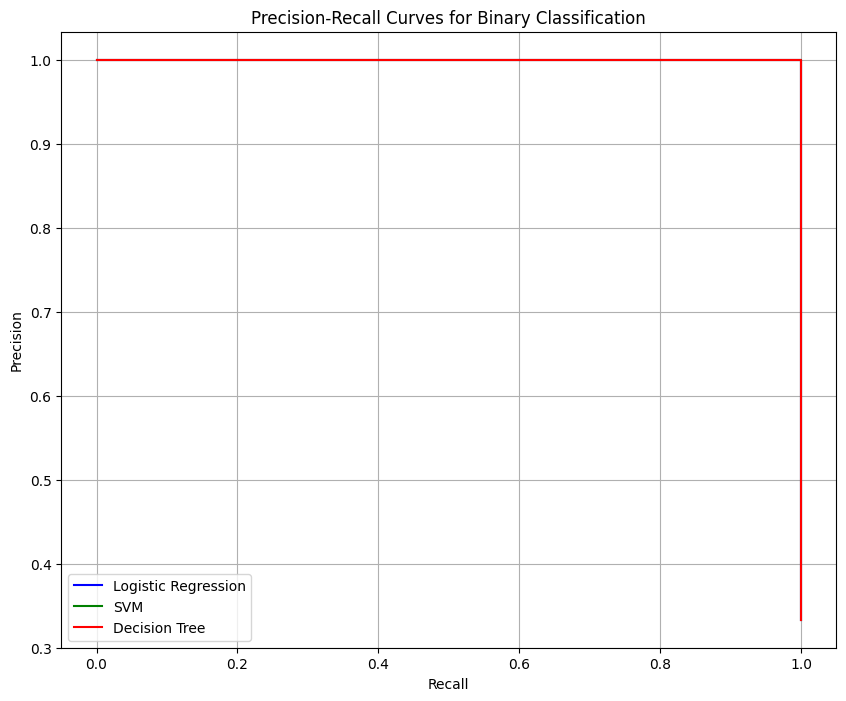

In [21]:
plt.figure(figsize=(10, 8))

# Loop through each model and its predicted probabilities
for i, (model_name, y_prob_data) in enumerate(models_binary_data.items()):
    # Compute Precision and Recall values
    precision, recall, _ = precision_recall_curve(y_test, y_prob_data[:, 1])
    # Plot Precision vs Recall curve for this model
    plt.plot(recall, precision, label=f'{model_name}', color=colors[i])

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Binary Classification')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Multiclass Classification (3 Classes)

In [22]:
# Split dataset again using original labels
X_train, X_test, y_train, y_test = train_test_split.train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [23]:
# Scale features
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
# Train Models Again
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [25]:
svm_model.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [26]:
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [27]:
y_pred_log = log_reg.predict(X_test)

In [28]:
y_pred_svm = svm_model.predict(X_test)

In [29]:
y_pred_tree = tree_model.predict(X_test)

In [30]:
print("Logistic Regression Report")
print(classification_report(y_test, y_pred_log))

print("SVM Report")
print(classification_report(y_test, y_pred_svm))

print("Decision Tree Report")
print(classification_report(y_test, y_pred_tree))

Logistic Regression Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

SVM Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Decision Tree Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.92      0.80      0.86        15
           2    

### Confusion Matrix

Logistic Regression Confusion Matrix


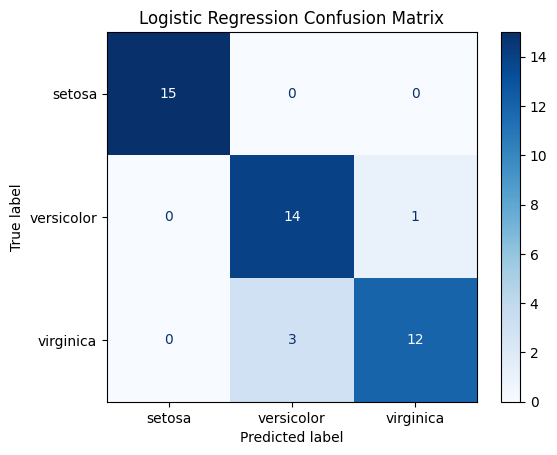

In [31]:
print("Logistic Regression Confusion Matrix")
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=iris.target_names)
disp_log.plot(cmap=plt.cm.Blues)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

SVM Confusion Matrix


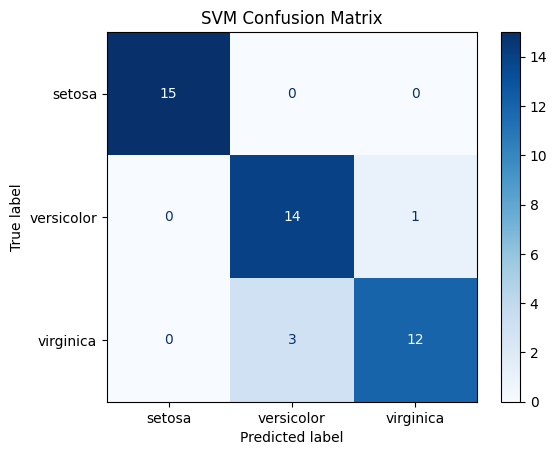

In [32]:
print("SVM Confusion Matrix")
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=iris.target_names)
disp_svm.plot(cmap=plt.cm.Blues)
plt.title('SVM Confusion Matrix')
plt.show()

Decision Tree Confusion Matrix


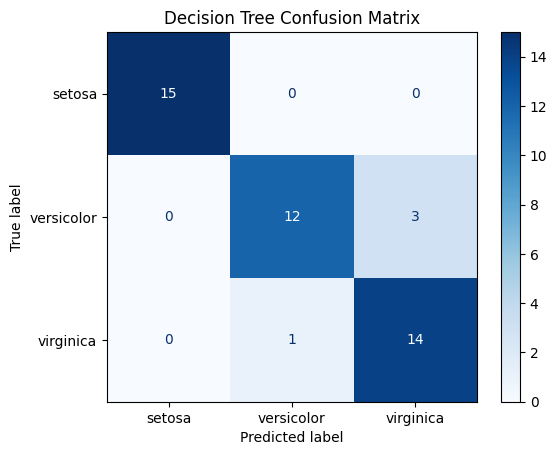

In [33]:
print("Decision Tree Confusion Matrix")
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=iris.target_names)
disp_tree.plot(cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix')
plt.show()